# 07. 최종 모델 성능 평가 (val_calib)

이 노트북은 `07_threshold_tuning.ipynb`에서 도출된 최적 임계값(`0.5720`, FPR 0.5% 상한 운영점)을 최종 모델에 고정(hardcode)한 후,
검증용 데이터인 `val_calib.parquet`를 사용하여 행 단위 성능을 평가합니다.

평가 결과로 **혼동 행렬(Confusion Matrix)**, **각종 분류 지표(Accuracy, Precision, Recall, Specificity, F1, MCC, FPR, FNR 등)** 및 **AUC 계열 그래프(ROC Curve, PR Curve)**를 출력합니다.

## 1. 환경 설정 및 라이브러리 로드

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))  # 프로젝트 루트 경로 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

import config.threshold_config as cfg
from src.eval_core import load_saved_ensemble

# 한글 폰트 설정
import matplotlib.font_manager as fm
def set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("✅ 환경 및 라이브러리 로드 완료")

✅ 환경 및 라이브러리 로드 완료


## 2. 저장된 최종 모델 및 데이터 로드

In [2]:
# 최종 앙상블 모델 및 피처 목록 로드
print("🔄 최종 모델 로드 중...")
artifacts = load_saved_ensemble(cfg, require_threshold=False)
feature_cols = artifacts["feature_cols"]
ensemble = artifacts["ensemble"]
print(f"✅ 모델 로드 완료: {len(feature_cols)}개 피처")

# val_calib 데이터셋 로드
print("🔄 val_calib 데이터 로드 중...")
val_calib_path = Path(cfg.VAL_CALIB_PATH)
df_val = pd.read_parquet(val_calib_path)
print(f"✅ 데이터 로드 완료: {len(df_val):,} 행")

🔄 최종 모델 로드 중...

[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (591 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (27 features)
  model: subset_00.pkl (9,539,044 bytes)
  model: subset_01.pkl (9,555,780 bytes)
  model: subset_02.pkl (9,557,204 bytes)
  model: subset_03.pkl (9,556,372 bytes)
  model: subset_04.pkl (9,563,556 bytes)
  model: subset_05.pkl (9,557,892 bytes)
  model: subset_06.pkl (9,558,804 bytes)
  model: subset_07.pkl (9,548,164 bytes)
  model: subset_08.pkl (9,552,068 bytes)
  model: subset_09.pkl (9,530,612 bytes)
  joblib 로드 1/10: subset_00.pkl
      → 0.3s
  joblib 로드 2/10: subset_01.pkl
      → 0.1s
  joblib 로드 3/10

## 3. 앙상블 예측 (Soft-Voting Probability)

In [ ]:
t0 = time.perf_counter()
print("🔄 앙상블 모델 예측 수행 중 (가장 오래 걸리는 단계)...")
y_prob = ensemble.predict_proba(df_val, feature_cols, verbose=True)
y_true = df_val[cfg.TARGET_COL].values
print(f"✅ 예측 완료! 소요 시간: {time.perf_counter() - t0:.1f}초")

🔄 앙상블 모델 예측 수행 중 (가장 오래 걸리는 단계)...
    모델 1/10 예측 중 (7,832,520행)...


## 4. 최종 운영 임계값 설정 (Hardcoded / Pinned)

In [ ]:
# best_threshold.json 에서 튜닝된 최적 파라미터 로드
import json
threshold_path = f"{cfg.MODEL_SAVE_DIR}/best_threshold.json"
try:
    with open(threshold_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    THRESHOLD = float(meta['threshold'])
    MIN_ALARMS = int(meta.get('min_alarms', 1))
    WINDOW_SIZE = meta.get('window_size', None)
    if WINDOW_SIZE is not None:
        WINDOW_SIZE = int(WINDOW_SIZE)
    print(f"📌 로드된 최적 임계값(Operating Threshold): {THRESHOLD:.6f}")
    print(f"📌 제약조건: min_alarms={MIN_ALARMS}, window_size={WINDOW_SIZE}")
except Exception as e:
    THRESHOLD = 0.5720
    MIN_ALARMS = 1
    WINDOW_SIZE = 14
    print(f"⚠️ 임계값 메타데이터 로드 실패 ({e}). 기본값 사용:")
    print(f"📌 THRESHOLD={THRESHOLD:.4f}, min_alarms={MIN_ALARMS}, window_size={WINDOW_SIZE}")


📌 고정 임계값(Operating Threshold): 0.5720


## 5. 행 단위 성능 지표 산출 및 리포트 출력

In [ ]:
# 이진 분류 결과 생성
y_pred = (y_prob >= THRESHOLD).astype(int)

# 혼동행렬 구성 요소 계산
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# 상세 평가 지표 계산
pr_auc = average_precision_score(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)  # TPR / Sensitivity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # TNR
f1 = f1_score(y_true, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

# 결과 출력
print("=" * 65)
print(f"  FINAL MODEL PERFORMANCE ON val_calib (Threshold = {THRESHOLD:.4f})")
print("=" * 65)
print(f"  Accuracy                      : {accuracy:.5f}")
print(f"  Precision (정밀도)             : {precision:.5f}")
print(f"  Recall (재현율, TPR)           : {recall:.5f}  ({recall*100:.2f}%)")
print(f"  Specificity (특이도, TNR)       : {specificity:.5f}  ({specificity*100:.2f}%)")
print(f"  F1-Score                      : {f1:.5f}")
print(f"  Matthews Correlation (MCC)    : {mcc:.5f}")
print(f"  False Positive Rate (FPR, 오탐율): {fpr:.5f}  ({fpr*100:.2f}%)")
print(f"  False Negative Rate (FNR, 미탐율): {fnr:.5f}  ({fnr*100:.2f}%)")
print(f"  ROC-AUC                       : {roc_auc:.5f}")
print(f"  PR-AUC (AUPRC)                : {pr_auc:.5f}")
print("=" * 65)
print(f"\n📢 요약: FPR {fpr*100:.2f}% 수준에서 고장 재현율 {recall*100:.2f}% 달성")
print("=" * 65)

print("\n[Classification Report]")
print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Failure (1)'], digits=5))

  FINAL MODEL PERFORMANCE ON val_calib (Threshold = 0.5720)
  Accuracy                      : 0.99461
  Precision (정밀도)             : 0.05970
  Recall (재현율, TPR)           : 0.44692  (44.69%)
  Specificity (특이도, TNR)       : 0.99500  (99.50%)
  F1-Score                      : 0.10533
  Matthews Correlation (MCC)    : 0.16189
  False Positive Rate (FPR, 오탐율): 0.00500  (0.50%)
  False Negative Rate (FNR, 미탐율): 0.55308  (55.31%)
  ROC-AUC                       : 0.83908
  PR-AUC (AUPRC)                : 0.12083

📢 요약: FPR 0.50% 수준에서 고장 재현율 44.69% 달성

[Classification Report]
              precision    recall  f1-score   support

  Normal (0)    0.99961   0.99500   0.99730   7826962
 Failure (1)    0.05970   0.44692   0.10533      5558

    accuracy                        0.99461   7832520
   macro avg    0.52965   0.72096   0.55131   7832520
weighted avg    0.99894   0.99461   0.99667   7832520



## 6. 오차 행렬 (Confusion Matrix) 시각화

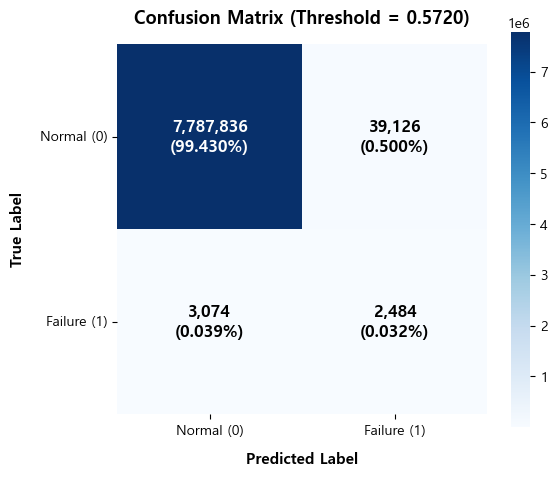

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=False, fmt='', cmap='Blues', cbar=True, square=True)

labels = ['Normal (0)', 'Failure (1)']
plt.xticks([0.5, 1.5], labels, fontsize=10)
plt.yticks([0.5, 1.5], labels, fontsize=10, rotation=0)
plt.xlabel('Predicted Label', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('True Label', fontsize=11, fontweight='bold', labelpad=10)
plt.title(f'Confusion Matrix (Threshold = {THRESHOLD:.4f})', fontsize=13, fontweight='bold', pad=15)

# 텍스트 추가 (빈도수 및 백분율)
total = cm.sum()
thresh = cm.max() / 2.
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = count / total * 100
        plt.text(j + 0.5, i + 0.5, f"{count:,}\n({pct:.3f}%)",
                 ha="center", va="center",
                 color="white" if count > thresh else "black",
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. AUC 계열 곡선 (ROC & Precision-Recall Curve) 시각화

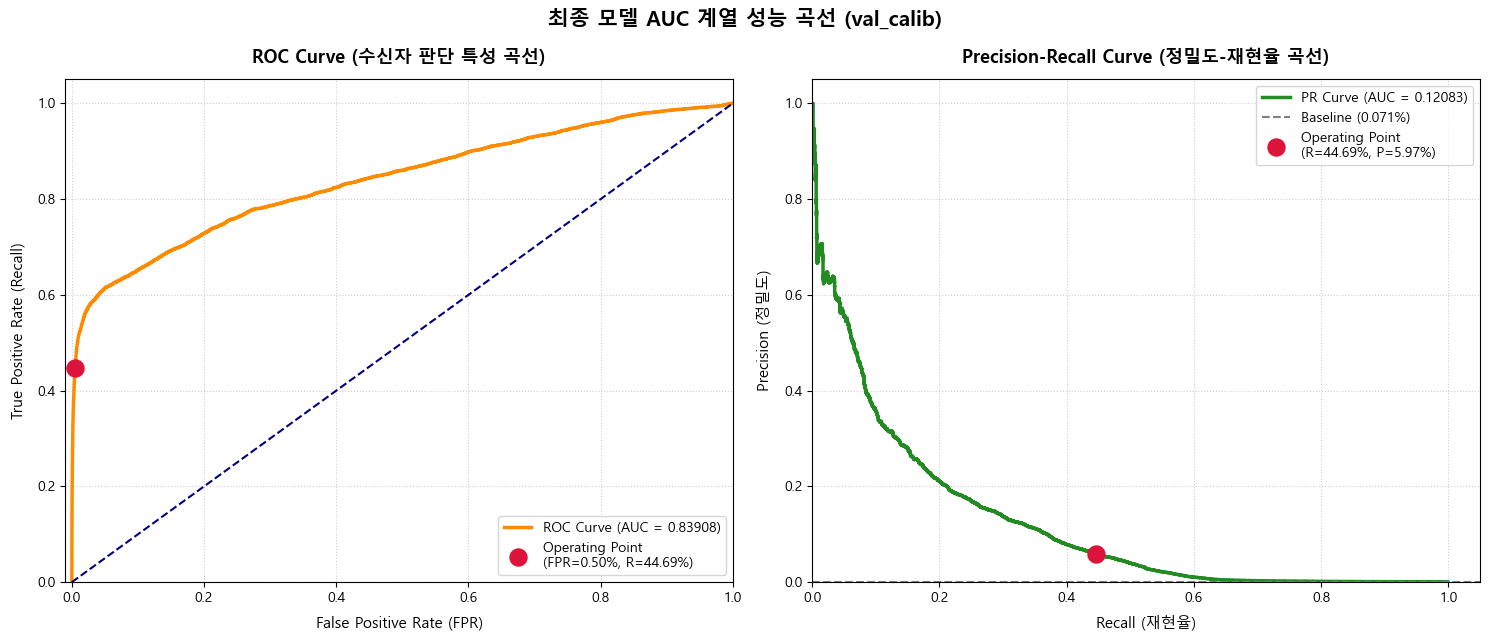

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# 1) ROC Curve
ax = axes[0]
fpr_rates, tpr_rates, _ = roc_curve(y_true, y_prob)
ax.plot(fpr_rates, tpr_rates, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.5f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
ax.scatter([fpr], [recall], color='crimson', s=150, zorder=5, 
           label=f'Operating Point\n(FPR={fpr*100:.2f}%, R={recall*100:.2f}%)')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11, labelpad=8)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11, labelpad=8)
ax.set_title('ROC Curve (수신자 판단 특성 곡선)', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

# 2) Precision-Recall Curve
ax = axes[1]
precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
ax.plot(recalls, precisions, color='forestgreen', lw=2.5, label=f'PR Curve (AUC = {pr_auc:.5f})')
baseline = y_true.sum() / len(y_true)
ax.axhline(baseline, color='gray', lw=1.5, linestyle='--', label=f'Baseline ({baseline*100:.3f}%)')
ax.scatter([recall], [precision], color='crimson', s=150, zorder=5, 
           label=f'Operating Point\n(R={recall*100:.2f}%, P={precision*100:.2f}%)')
ax.set_xlim([0.0, 1.05])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (재현율)', fontsize=11, labelpad=8)
ax.set_ylabel('Precision (정밀도)', fontsize=11, labelpad=8)
ax.set_title('Precision-Recall Curve (정밀도-재현율 곡선)', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle(f'최종 모델 AUC 계열 성능 곡선 (val_calib)', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 8. 서브셋 모델별 PR-AUC 비교 시각화

ℹ️ 이전 단계에서 계산된 서브셋별 예측 확률을 재사용합니다.
Subset 01 PR-AUC: 0.10684
Subset 02 PR-AUC: 0.10741
Subset 03 PR-AUC: 0.11121
Subset 04 PR-AUC: 0.11081
Subset 05 PR-AUC: 0.10365
Subset 06 PR-AUC: 0.11438
Subset 07 PR-AUC: 0.10864
Subset 08 PR-AUC: 0.11042
Subset 09 PR-AUC: 0.09689
Subset 10 PR-AUC: 0.10982


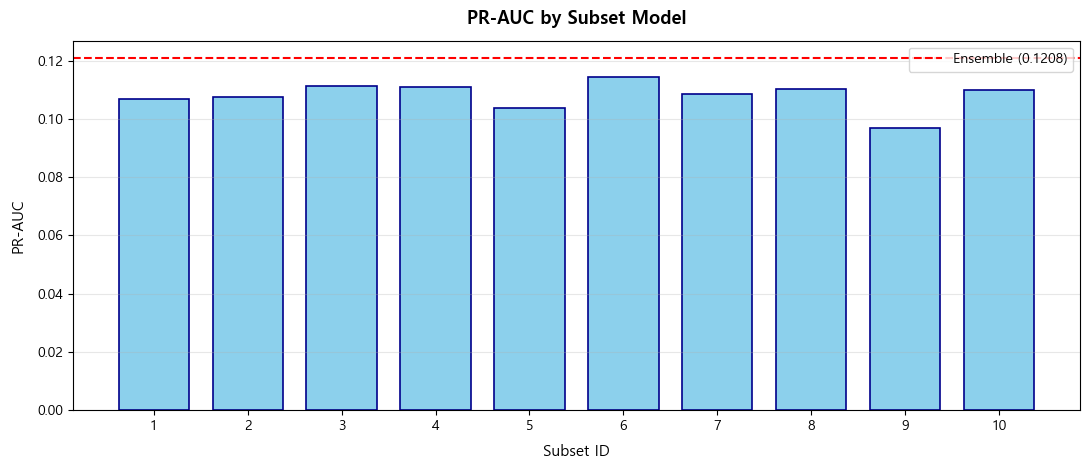

In [ ]:
# 각 개별 서브셋 모델의 예측 확률 및 PR-AUC 계산 (재추론 없이 캐싱된 결과 사용)
subset_pr_aucs = []
if getattr(ensemble, 'last_probs', None) is not None:
    print("ℹ️ 이전 단계에서 계산된 서브셋별 예측 확률을 재사용합니다.")
    for i, y_prob_sub in enumerate(ensemble.last_probs):
        pr_auc_sub = average_precision_score(y_true, y_prob_sub)
        subset_pr_aucs.append(pr_auc_sub)
        print(f"Subset {i+1:02d} PR-AUC: {pr_auc_sub:.5f}")
else:
    X_val = df_val[feature_cols].astype(np.float32)
    for i, model in enumerate(ensemble.models):
        y_prob_sub = model.predict_proba(X_val)[:, 1]
        pr_auc_sub = average_precision_score(y_true, y_prob_sub)
        subset_pr_aucs.append(pr_auc_sub)
        print(f"Subset {i+1:02d} PR-AUC: {pr_auc_sub:.5f}")

# 시각화 설정
plt.figure(figsize=(11, 4.8))
subset_ids = np.arange(1, 11)

# 막대 그래프 그리기 (하늘색 채우기, 진한 파란색 테두리)
bars = plt.bar(subset_ids, subset_pr_aucs, color='#8cd0ec', edgecolor='darkblue', linewidth=1.2, width=0.75)

# 앙상블 모델 전체 PR-AUC 기준선 (빨간색 점선)
plt.axhline(pr_auc, color='red', linestyle='--', linewidth=1.5, label=f'Ensemble ({pr_auc:.4f})')

# 축 및 레이블 설정
plt.title('PR-AUC by Subset Model', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Subset ID', fontsize=11, labelpad=8)
plt.ylabel('PR-AUC', fontsize=11, labelpad=8)
plt.xticks(subset_ids, fontsize=10)
plt.yticks(fontsize=10)

# 가로 그리드 설정
plt.grid(axis='y', linestyle='-', alpha=0.3)
plt.legend(loc='upper right', fontsize=10)

# 여백 조정 및 출력
plt.tight_layout()
plt.show()

## 9. 시리얼 번호(디스크) 단위 성능 평가 (Base Serial Level)

행 단위 평가와 더불어, 실제 운영 환경에서의 디스크 교체 의사결정 단위인 **시리얼 번호(디스크) 기준**의 성능을 평가합니다.
- 시리얼 번호 끝의 `_1`, `_2`, `_3` 등 sampling/windowing 과정에서 생성된 접미사(suffix)는 무시하고 동일 디스크(`base_serial`)로 병합하여 집계합니다.
- **전체 기간 알람 (Anytime Alarm)**: 디스크 관측 전체 기간 중 단 1회라도 예측 확률이 임계값을 넘으면 고장 알람을 발생시킨 것으로 간주합니다.
- **고장 직전 10일 알람 (Failure Window Alarm)**: 실제 고장 데이터(failure == 1)가 존재하는 10일 구간 내에 알람이 정상적으로 발생했는지를 평가합니다.

🔄 디스크 단위 데이터 집계 중...
  DISK-LEVEL PERFORMANCE EVALUATION (Base Serial, Threshold = 0.5720)
  Total Disks (총 디스크 수)     : 3,691
    - Failed Disks (고장 디스크) : 565
    - Normal Disks (정상 디스크) : 3,126
-----------------------------------------------------------------
  [1. 전체 기간 알람 기준 (Anytime Alarm)]
    - Confusion Matrix          : TP=390, FN=175, FP=300, TN=2826
    - Hit Rate (고장 탐지율)      : 0.69027 (69.03%)
    - False Alarm Rate (오탐율)  : 0.09597 (9.60%)
    - Precision (정밀도)         : 0.56522
    - F1-Score                  : 0.62151
-----------------------------------------------------------------
  [2. 고장 직전 최초 알람 리드 타임 (Lead Time)]
    - 평균 사전 경보 시간 (Mean Lead Time)   : 213.90일
    - 중앙값 사전 경보 시간 (Median Lead Time) : 56.5일
    - 최소 사전 경보 시간 (Min Lead Time)    : 0일
    - 최대 사전 경보 시간 (Max Lead Time)    : 2266일
-----------------------------------------------------------------
  [3. 정상 디스크 (비고장 레이블) 오탐 상세 집계]
    - 오탐 발생 정상 디스크 수   : 300대 / 3,126대 (9.597%)
    - 디스크별 평균 오탐 일수   : 46.4

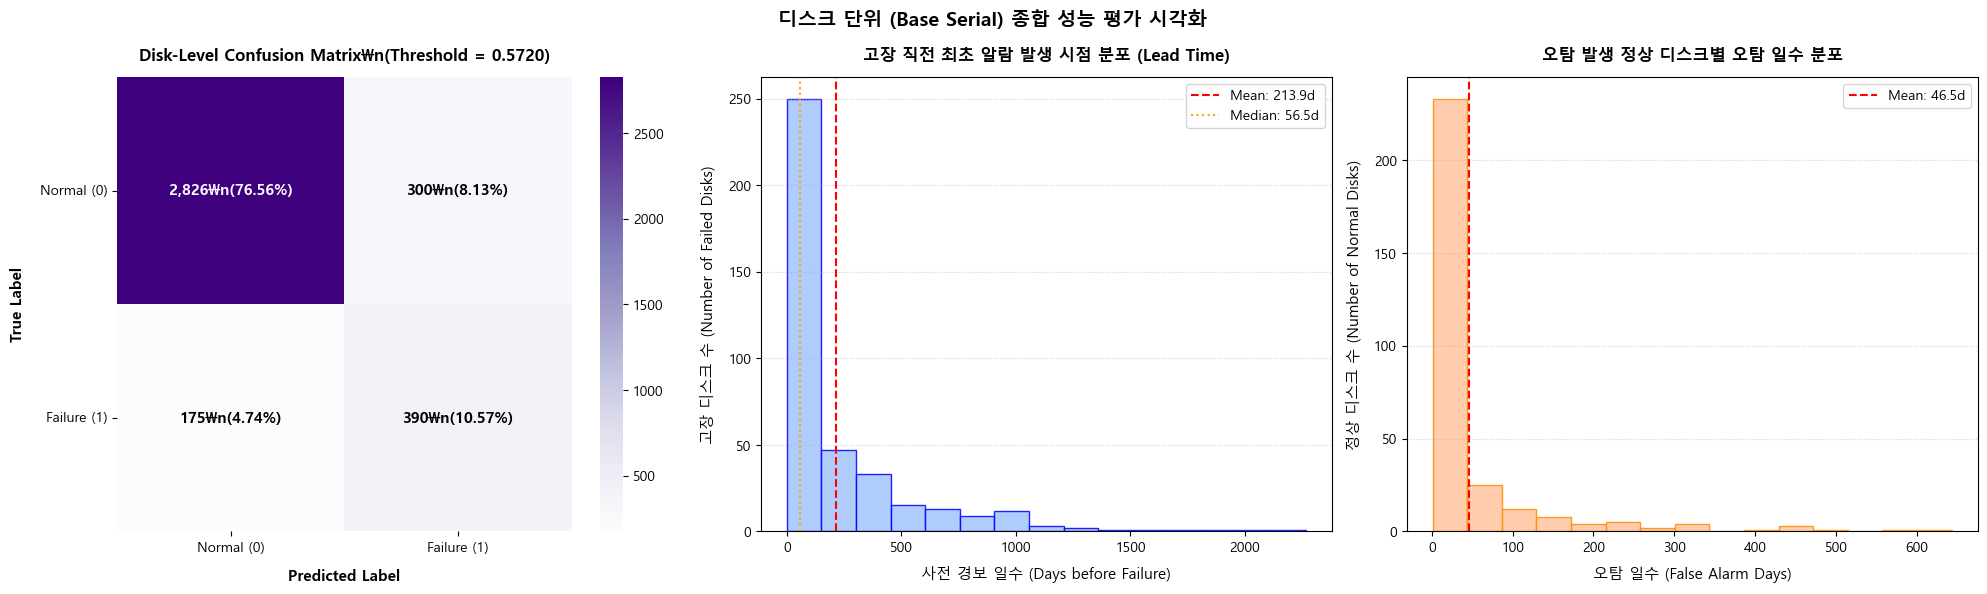

In [ ]:
# 1. Base serial number 생성 (접미사 _d+ 제거) 및 날짜 타입 변환
df_val['base_serial'] = df_val[cfg.SERIAL_COL].str.replace(r'_\d+$', '', regex=True)
df_val['date'] = pd.to_datetime(df_val[cfg.DATE_COL])
df_val['y_prob'] = y_prob
y_pred = (y_prob >= THRESHOLD).astype(int)
df_val['y_pred'] = y_pred

# 2. EntityLevelEvaluator를 이용한 롤링 알람 탐지 적용
print("🔄 EntityLevelEvaluator를 사용하여 롤링 알람 탐지 수행 중...")
from src.eval_core import EntityLevelEvaluator
ev = EntityLevelEvaluator(serial_col='base_serial', date_col='date', target_col=cfg.TARGET_COL)
eval_res = ev.evaluate(df_val, y_prob, threshold=THRESHOLD, min_alarms=MIN_ALARMS, window_size=WINDOW_SIZE)

entity_df = eval_res['entity_df'].set_index('serial_number')

# 3. 디스크 단위 데이터 집계 (Vectorized Groupby)
is_failed_disk = df_val.groupby('base_serial')[cfg.TARGET_COL].max()
min_date = df_val.groupby('base_serial')['date'].min()
max_date = df_val.groupby('base_serial')['date'].max()
obs_days = df_val.groupby('base_serial').size()
total_alarm_days = df_val.groupby('base_serial')['y_pred'].sum()

# 고장 디스크 중 실제 고장 구간(failure == 1인 행들)에서의 알람 집계
df_failure_rows = df_val[df_val[cfg.TARGET_COL] == 1]
has_alarm_in_failure_window = df_failure_rows.groupby('base_serial')['y_pred'].max()
alarm_days_in_failure_window = df_failure_rows.groupby('base_serial')['y_pred'].sum()
total_failure_days = df_failure_rows.groupby('base_serial').size()

# 디스크 단위 DataFrame 생성
df_disk = pd.DataFrame(index=is_failed_disk.index)
df_disk['is_failed'] = is_failed_disk
df_disk['has_alarm_anytime'] = entity_df['has_alarm'].reindex(df_disk.index, fill_value=0)
df_disk['min_date'] = min_date
df_disk['max_date'] = max_date
df_disk['obs_days'] = obs_days
df_disk['total_alarm_days'] = total_alarm_days
df_disk['first_alarm_date'] = entity_df['first_alarm_date'].reindex(df_disk.index)
df_disk['alarm_in_failure_window'] = has_alarm_in_failure_window.reindex(df_disk.index, fill_value=0)
df_disk['alarm_days_in_failure_window'] = alarm_days_in_failure_window.reindex(df_disk.index, fill_value=0)
df_disk['total_failure_days'] = total_failure_days.reindex(df_disk.index, fill_value=0)

# Lead Time 계산 (EntityLevelEvaluator에서 계산된 값 reindex)
df_disk['lead_time'] = entity_df['lead_time_days'].reindex(df_disk.index)

# 3. 디스크 단위 혼동 행렬 및 분류 지표 계산
n_total_disks = len(df_disk)
n_failed_disks = int(df_disk['is_failed'].sum())
n_normal_disks = n_total_disks - n_failed_disks

# 전체 기간 알람 기준 혼동 행렬
tp_disk = int(((df_disk['is_failed'] == 1) & (df_disk['has_alarm_anytime'] == 1)).sum())
fn_disk = int(((df_disk['is_failed'] == 1) & (df_disk['has_alarm_anytime'] == 0)).sum())
fp_disk = int(((df_disk['is_failed'] == 0) & (df_disk['has_alarm_anytime'] == 1)).sum())
tn_disk = int(((df_disk['is_failed'] == 0) & (df_disk['has_alarm_anytime'] == 0)).sum())

# 평가지표 산출 (EntityLevelEvaluator 결과와 정합성을 이룸)
hit_rate_disk = tp_disk / n_failed_disks if n_failed_disks > 0 else 0.0
fa_rate_disk = fp_disk / n_normal_disks if n_normal_disks > 0 else 0.0
precision_disk = tp_disk / (tp_disk + fp_disk) if (tp_disk + fp_disk) > 0 else 0.0
f1_disk = 2 * precision_disk * hit_rate_disk / (precision_disk + hit_rate_disk) if (precision_disk + hit_rate_disk) > 0 else 0.0

# 고장 구간(10일) 내 알람 기준 평가지표
df_failed_only = df_disk[df_disk['is_failed'] == 1]
tp_window = int(df_failed_only['alarm_in_failure_window'].sum())
hit_rate_window = tp_window / n_failed_disks if n_failed_disks > 0 else 0.0
mean_alarm_days = df_failed_only['alarm_days_in_failure_window'].mean()

# Lead Time 상세 통계 (탐지 성공한 고장 디스크 대상)
detected_failed_disks = df_disk[(df_disk['is_failed'] == 1) & (df_disk['has_alarm_anytime'] == 1)]
lead_times = detected_failed_disks['lead_time'].dropna()

# 정상 디스크 오탐 상세 통계 (오탐이 발생한 정상 디스크 대상)
normal_disks_with_fa = df_disk[(df_disk['is_failed'] == 0) & (df_disk['has_alarm_anytime'] == 1)]

# 결과 출력
print("=" * 65)
print(f"  DISK-LEVEL PERFORMANCE EVALUATION (Base Serial, Threshold = {THRESHOLD:.4f})")
print("=" * 65)
print(f"  Total Disks (총 디스크 수)     : {n_total_disks:,}")
print(f"    - Failed Disks (고장 디스크) : {n_failed_disks:,}")
print(f"    - Normal Disks (정상 디스크) : {n_normal_disks:,}")
print("-" * 65)
print(f"  [1. 전체 기간 알람 기준 (Rolling Alarm W={WINDOW_SIZE}, n={MIN_ALARMS})]")
print(f"    - Confusion Matrix          : TP={tp_disk}, FN={fn_disk}, FP={fp_disk}, TN={tn_disk}")
print(f"    - Hit Rate (고장 탐지율)      : {hit_rate_disk:.5f} ({hit_rate_disk*100:.2f}%)")
print(f"    - False Alarm Rate (오탐율)  : {fa_rate_disk:.5f} ({fa_rate_disk*100:.2f}%)")
print(f"    - Precision (정밀도)         : {precision_disk:.5f}")
print(f"    - F1-Score                  : {f1_disk:.5f}")
print("-" * 65)
print("  [2. 고장 직전 최초 알람 리드 타임 (Lead Time)]")
if len(lead_times) > 0:
    print(f"    - 평균 사전 경보 시간 (Mean Lead Time)   : {lead_times.mean():.2f}일")
    print(f"    - 중앙값 사전 경보 시간 (Median Lead Time) : {lead_times.median():.1f}일")
    print(f"    - 최소 사전 경보 시간 (Min Lead Time)    : {lead_times.min():.0f}일")
    print(f"    - 최대 사전 경보 시간 (Max Lead Time)    : {lead_times.max():.0f}일")
else:
    print("    - 탐지 성공한 고장 디스크가 없어 리드 타임을 산출할 수 없습니다.")
print("-" * 65)
print("  [3. 정상 디스크 (비고장 레이블) 오탐 상세 집계]")
if len(normal_disks_with_fa) > 0:
    mean_fa_days = normal_disks_with_fa['total_alarm_days'].mean()
    max_fa_days = normal_disks_with_fa['total_alarm_days'].max()
    fa_ratio_per_disk = (normal_disks_with_fa['total_alarm_days'] / normal_disks_with_fa['obs_days']).mean()
    print(f"    - 오탐 발생 정상 디스크 수   : {len(normal_disks_with_fa):,}대 / {n_normal_disks:,}대 ({len(normal_disks_with_fa)/n_normal_disks*100:.3f}%)")
    print(f"    - 디스크별 평균 오탐 일수   : {mean_fa_days:.2f}일 (최대 {max_fa_days:.0f}일)")
    print(f"    - 디스크별 평균 오탐 비율   : {fa_ratio_per_disk*100:.3f}% (오탐일수/관측일수)")
else:
    print("    - 오탐이 발생한 정상 디스크가 없습니다 (오탐율 0%).")
print("-" * 65)
print("  [4. 고장 직전 10일 구간 내 알람 기준 (Failure Window Alarm)]")
print(f"    - Failure Window Hit Rate   : {hit_rate_window:.5f} ({hit_rate_window*100:.2f}%)")
print("      (고장 직전 10일 중 최소 1회 이상 탐지한 비율)")
print(f"    - Mean Alarm Days           : {mean_alarm_days:.2f}일 / 10일")
print("      (고장 직전 10일 중 평균 알람 발생 일수)")
print("=" * 65)

# 4. 시각화 (1행 3열 구성: 오차행렬, 리드타임 분포, 정상 디스크 오탐일수 분포)
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) 디스크 단위 혼동 행렬 시각화
ax = axes[0]
cm_disk = np.array([[tn_disk, fp_disk], [fn_disk, tp_disk]])
sns.heatmap(cm_disk, annot=False, fmt='', cmap='Purples', cbar=True, square=True, ax=ax)
labels = ['Normal (0)', 'Failure (1)']
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(labels, fontsize=10, rotation=0)
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('True Label', fontsize=11, fontweight='bold', labelpad=10)
ax.set_title(f'Disk-Level Confusion Matrix\\n(Threshold = {THRESHOLD:.4f})', fontsize=12, fontweight='bold', pad=12)

total_d = cm_disk.sum()
thresh_d = cm_disk.max() / 2.
for i in range(2):
    for j in range(2):
        count = cm_disk[i, j]
        pct = count / total_d * 100
        ax.text(j + 0.5, i + 0.5, f"{count:,}\\n({pct:.2f}%)",
                 ha="center", va="center",
                 color="white" if count > thresh_d else "black",
                 fontsize=11, fontweight='bold')

# 2) 고장 직전 최초 알람 발생 시점 분포 (Lead Time)
ax = axes[1]
if len(lead_times) > 0:
    ax.hist(lead_times, bins=15, color='#a1c4fd', edgecolor='blue', linewidth=1.0, alpha=0.85)
    ax.axvline(lead_times.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {lead_times.mean():.1f}d')
    ax.axvline(lead_times.median(), color='orange', linestyle=':', linewidth=1.5, label=f'Median: {lead_times.median():.1f}d')
    ax.set_xlabel('사전 경보 일수 (Days before Failure)', fontsize=11, labelpad=8)
    ax.set_ylabel('고장 디스크 수 (Number of Failed Disks)', fontsize=11, labelpad=8)
    ax.set_title('고장 직전 최초 알람 발생 시점 분포 (Lead Time)', fontsize=12, fontweight='bold', pad=12)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    ax.legend()
else:
    ax.text(0.5, 0.5, '탐지된 고장 디스크 없음', ha='center', va='center', fontsize=12)
    ax.set_title('고장 직전 최초 알람 발생 시점 분포 (Lead Time)', fontsize=12, fontweight='bold', pad=12)

# 3) 정상 디스크의 오탐 발생 일수 분포
ax = axes[2]
if len(normal_disks_with_fa) > 0:
    fa_days = normal_disks_with_fa['total_alarm_days']
    ax.hist(fa_days, bins=15, color='#ffc3a0', edgecolor='darkorange', linewidth=1.0, alpha=0.85)
    ax.axvline(fa_days.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {fa_days.mean():.1f}d')
    ax.set_xlabel('오탐 일수 (False Alarm Days)', fontsize=11, labelpad=8)
    ax.set_ylabel('정상 디스크 수 (Number of Normal Disks)', fontsize=11, labelpad=8)
    ax.set_title('오탐 발생 정상 디스크별 오탐 일수 분포', fontsize=12, fontweight='bold', pad=12)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    ax.legend()
else:
    ax.text(0.5, 0.5, '오탐이 발생한 정상 디스크 없음', ha='center', va='center', fontsize=12)
    ax.set_title('오탐 발생 정상 디스크별 오탐 일수 분포', fontsize=12, fontweight='bold', pad=12)

plt.suptitle('디스크 단위 (Base Serial) 종합 성능 평가 시각화', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
